sumber data : data terbuka, dari kaggle.com
minat: berkaitan dengan dunia pendidikan,

Permasalahan yang dikaji dalam penelitian ini adalah bagaimana prestasi belajar siswa (nilai ujian) dipengaruhi oleh berbagai faktor, seperti jenis kelamin, ras/etnis, tingkat pendidikan orang tua, jenis konsumsi makan siang, serta keikutsertaan dalam program persiapan ujian

In [1]:
# import os
# gdrive_path = '/content/drive/MyDrive/Colab_Notebooks'
# os.chdir(gdrive_path)
# os.getcwd()

1.Impor Paket library yang akan du gunakan

In [33]:
import pandas as pd                                                #Mengolah data dalam bentuk tabel (DataFrame)
import numpy as np                                                  #Mengolah data angka (numerik)
import matplotlib.pyplot as plt                                     #Membuat grafik dasar ,histogrsm dll, line chart
import seaborn as sns                                               #Membuat visualisasi data yang lebih menarik,Heatmap, pairplot, boxplot, distribusi data
import warnings
warnings.filterwarnings('ignore')                                    #Menyembunyikan pesan peringatan (warning)
from sklearn.model_selection import train_test_split                 #Untuk membagi dataset menjadi:data training (melatih model)data testing (mengevaluasi model)
from sklearn.preprocessing import StandardScaler                     #Menormalkan / standardisasi data
from sklearn.metrics import accuracy_score, classification_report    #Untuk mengukur akurasi model ML,classification_report Menampilkan:precision, recall, f1-score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC                                          #Support Vector Machine,Klasifikasi dengan hyperplane ,Sangat akurat dalam data kompleks, Perlu scaling (StandardScaler)
from sklearn.neighbors import KNeighborsClassifier                    #KNN,Mengklasifikasi berdasarkan jarak terdekatCocok untuk dataset kecil

In [34]:
#from google.colab import drive
#lokasi_drive = '/content/drive/MyDrive/Colab_Notebooks/StudentsPerformance.csv'
#df = pd.read_csv(lokasi_drive)
df=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/StudentsPerformance.csv")#https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


Data Exploration

In [35]:
df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [36]:
df.duplicated().any()

np.False_

In [6]:
#pembesihan data
df=df.drop_duplicates()

In [37]:
print(df['gender'].duplicated().sum())

998


In [38]:
df.columns # menyajikan kolom

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.isnull().sum() #3.1Memeriksa Nilai yang kosong

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [11]:
numerical=df.select_dtypes(include=np.number).columns
print("Numerical:",numerical)
categorical=df.select_dtypes(include=object).columns
print("Categorical:",categorical)

Numerical: Index(['math score', 'reading score', 'writing score'], dtype='object')
Categorical: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
df['gender'].value_counts()

,count
gender,
female,518
male,482


In [14]:
df['parental level of education'].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


In [15]:
df['test preparation course'].value_counts()

,count
test preparation course,
none,642
completed,358


In [16]:
#Feature Engineering
df['total_marks']=df['math score']+df['reading score']+df['writing score']
df['total_marks']

,total_marks
0,218
1,247
2,278
3,148
4,229
...,...
995,282
996,172
997,195
998,223


In [17]:
df['percentage']=df['total_marks']/300*100
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_marks,percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


In [18]:
df['grade'] = pd.cut(df['percentage'],
                     bins=[0, 50, 65, 80, 100],
                     labels=['Fail', 'Average', 'Good', 'Excellent'])

mengelompokkan rentang nilai 0-100, menjadi 5 bagian

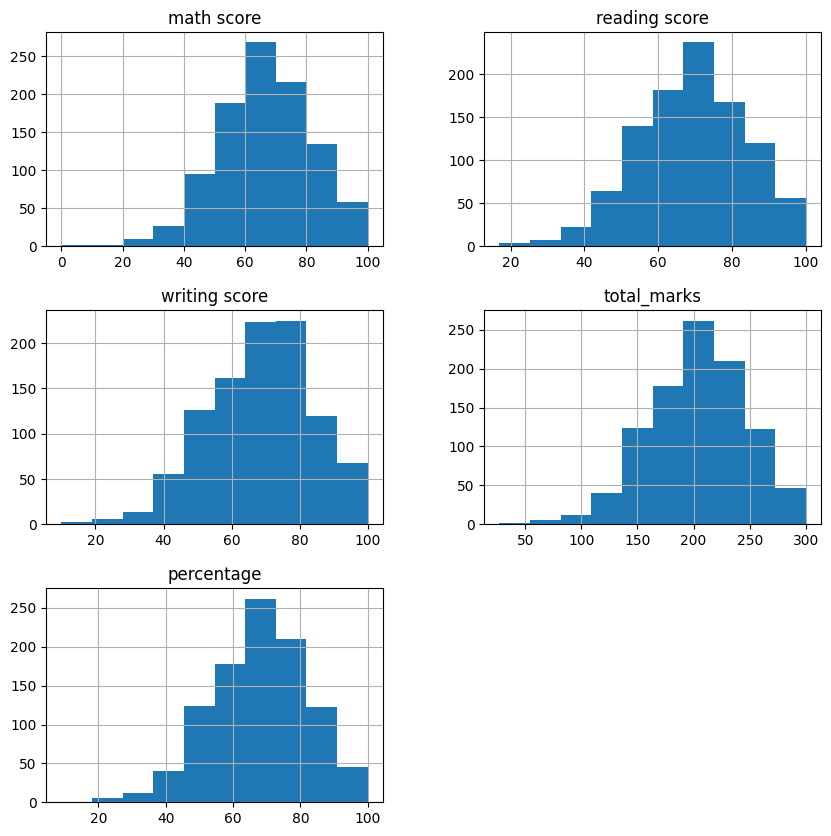

In [19]:
#visualisasi Data
df.hist(bins=10,figsize=(10,10))
plt.show()

<Axes: xlabel='lunch'>

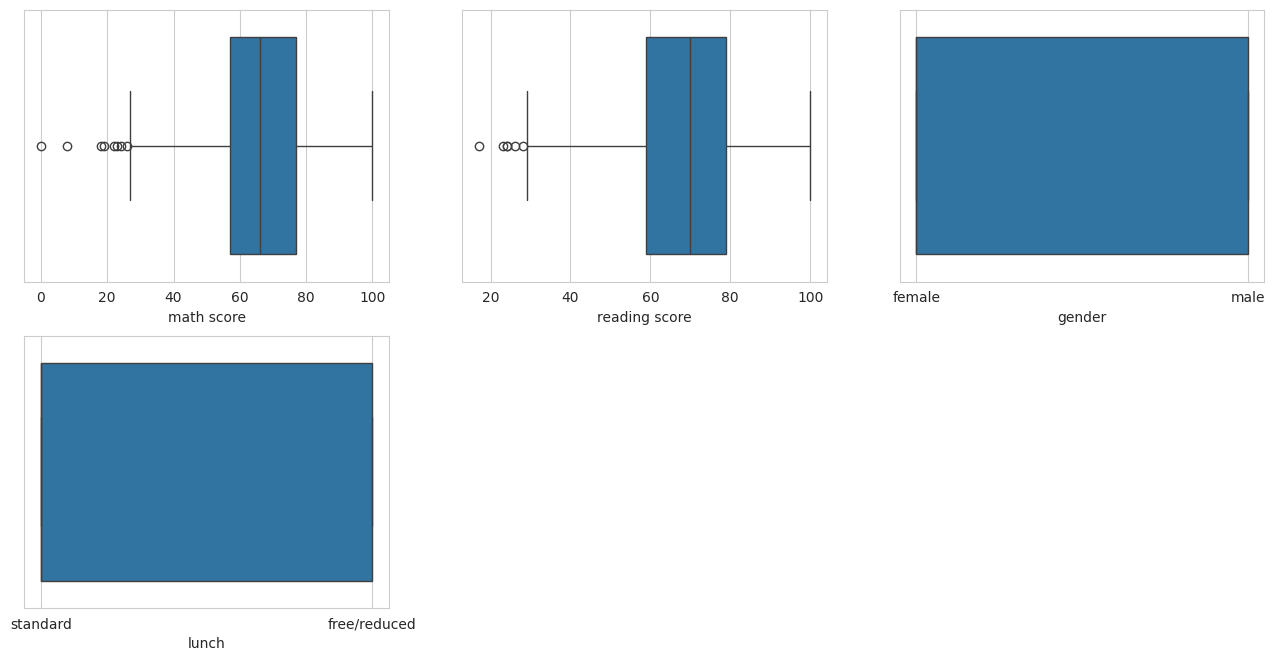

In [20]:
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(x='math score',data=df)
plt.subplot(3,3,2)
sns.boxplot(x='reading score',data=df)
plt.subplot(3,3,3)
sns.boxplot(x='gender',data=df)
plt.subplot(3,3,4)
sns.boxplot(x='lunch',data=df)

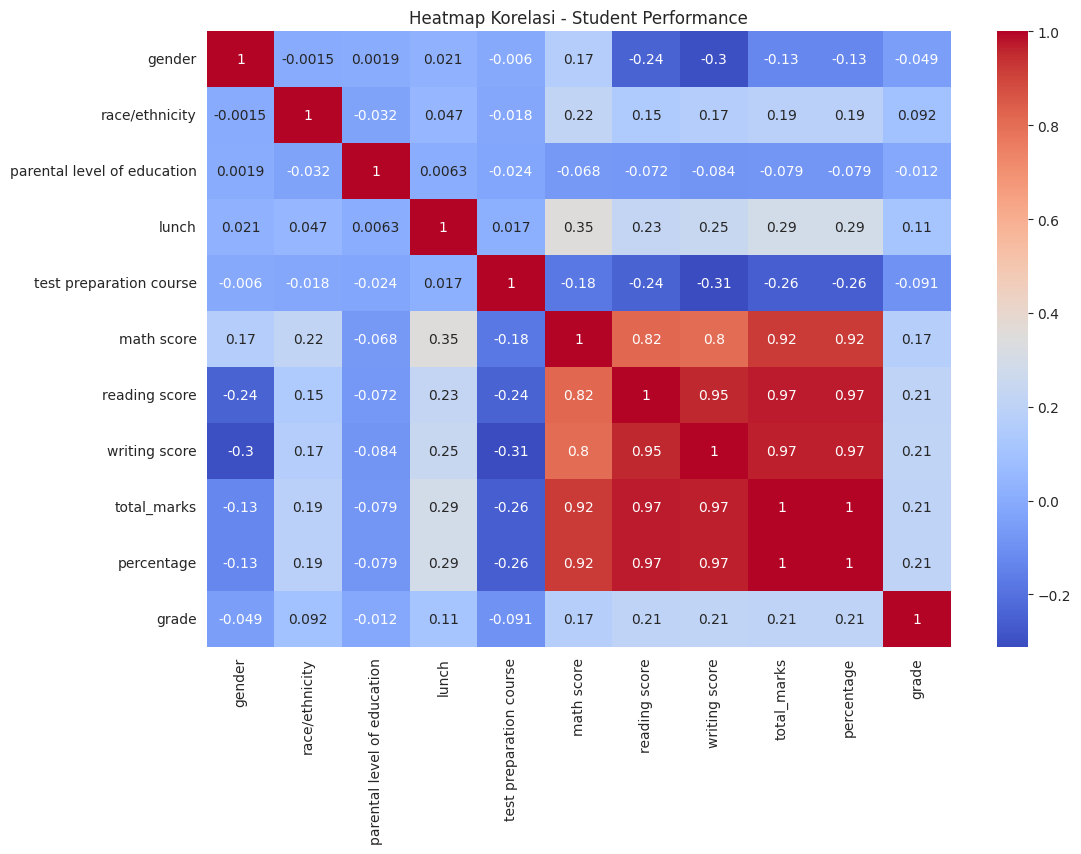

In [21]:
from sklearn.preprocessing import LabelEncoder

#kontruksi data
#seleksi fitur
# 2. Identifikasi kolom categorical (string dan category)
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 3. Encode semua kolom kategori dengan LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 4. Hitung matriks korelasi
corrmat = df.corr()

# 5. Visualisasi heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corrmat, annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi - Student Performance")
plt.show()

In [22]:
df_selected = df.drop(
    ['gender', 'race/ethnicity', 'parental level of education',
     'lunch', 'test preparation course'],
    axis='columns'
)

In [23]:
from sklearn.preprocessing import QuantileTransformer  #Membuat objek transformer.0-1
x=df_selected
quantile  = QuantileTransformer()
X = quantile.fit_transform(x)
df_new=quantile.transform(X)
df_new=pd.DataFrame(X)
df_new.columns =['math score', 'reading score','writing score', 'total_marks', 'percentage', 'grade']
df_new.head()

,math score,reading score,writing score,total_marks,percentage,grade
0,0.644144,0.550050,0.632633,0.617117,0.617117,1.000000
1,0.575075,0.929429,0.907908,0.840841,0.840841,0.396396
2,0.946446,0.967467,0.956456,0.968969,0.968969,0.396396
3,0.101101,0.200200,0.065566,0.097598,0.097598,0.547548
4,0.737237,0.718719,0.661161,0.716216,0.716216,1.000000


<Axes: xlabel='writing score'>

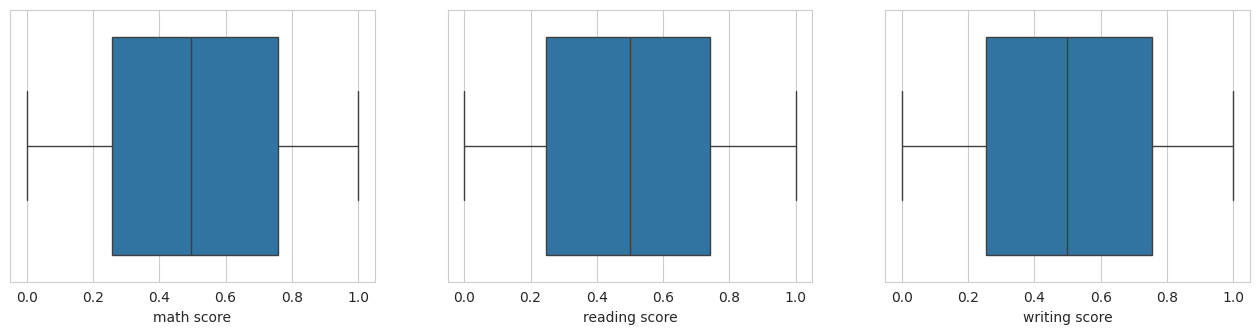

In [24]:
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(x='math score',data=df_new)
plt.subplot(3,3,2)
sns.boxplot(x='reading score',data=df_new)
plt.subplot(3,3,3)
sns.boxplot(x='writing score',data=df_new)


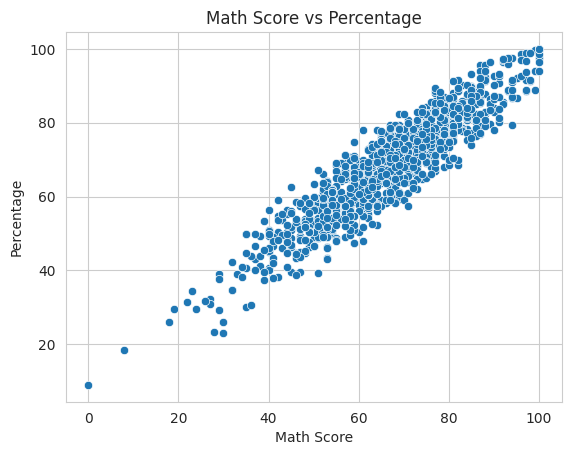

In [25]:
sns.scatterplot(data=df,x='math score',y='percentage')
plt.title('Math Score vs Percentage')
plt.xlabel('Math Score')
plt.ylabel('Percentage')
plt.show()

Ada hubungan kuat antara Math Score dan Percentage:
 Semakin tinggi nilai matematika, semakin tinggi persentase nilai total
 Grafik membantu melihat pola prestasi siswa
 Grafik ini termasuk visualisasi korelasi antar fitur
Scatterplot membantu mendeteksi outlier

Mengelompokkan Gender

 Bagaimana Distribusi jenis Kelamin
 apakah Gender  mempengaruhi performa siswa


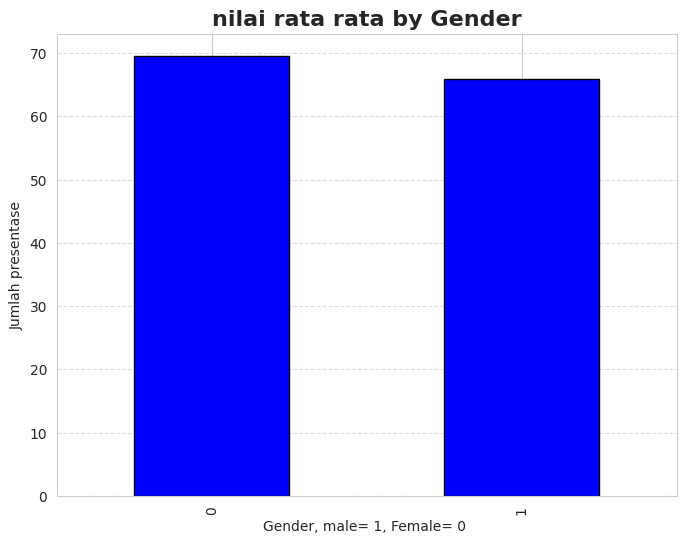

In [26]:
df.groupby('gender')['percentage'].mean().plot(
    kind='bar',
    color='blue',
    figsize=(8,6),
    edgecolor='black'
)

plt.title('nilai rata rata by Gender', fontsize=16, weight='bold')
#plt.title('Gender male=1, Fimale=0', fontsize=16, weight='bold')

plt.xlabel('Gender, male= 1, Female= 0 ')
plt.ylabel('Jumlah presentase')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
#memisahkan fitur dan TARGET
X = df.drop(['percentage', 'total_marks', 'grade'], axis=1)
y = df['grade']

In [28]:
#One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [29]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
#kLASIFIKASI model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


In [31]:
#LATIH, PREDIKSI, DAN EVALUASI
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n {name} ")
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, y_pred))


 Logistic Regression 
Accuracy: 0.865
              precision    recall  f1-score   support

           0       0.82      0.92      0.87        60
           1       0.89      0.85      0.87        39
           2       1.00      0.55      0.71        22
           3       0.87      0.92      0.90        79

    accuracy                           0.86       200
   macro avg       0.90      0.81      0.83       200
weighted avg       0.87      0.86      0.86       200


 Decision Tree 
Accuracy: 0.935
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        60
           1       0.97      0.92      0.95        39
           2       0.87      0.91      0.89        22
           3       0.94      0.96      0.95        79

    accuracy                           0.94       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.94      0.94      0.94       200


 Random Forest 
Accuracy: 0.95
              precision   

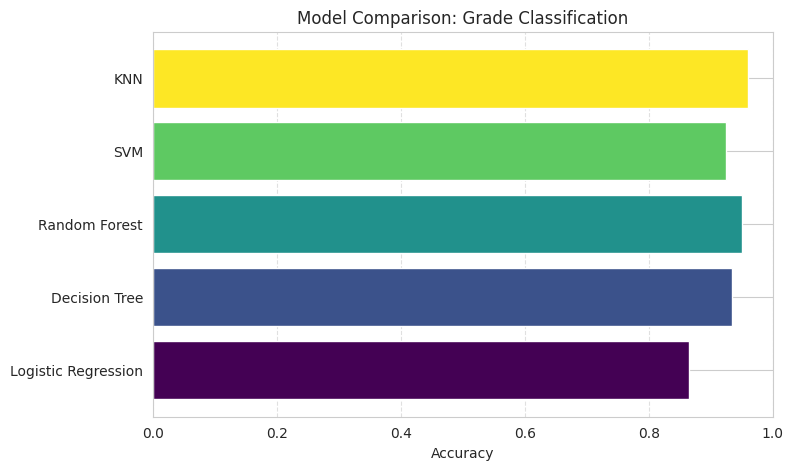

In [32]:
# KEMUDIAN BANDINGKAN KINERJA MODEL
plt.figure(figsize=(8,5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
plt.barh(list(results.keys()), list(results.values()), color=colors)
plt.xlabel('Accuracy')
plt.title('Model Comparison: Grade Classification')
plt.xlim(0,1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Perbandingan lima model klasifikasi, yaitu Logistic Regression, Decision Tree, Random Forest, SVM, and KNN, menunjukkan bahwa semuanya berkinerja baik dalam memprediksi kategori nilai siswa. KNN mencapai akurasi tertinggi (≈96%), diikuti oleh Random Forest (95%) dan Decision Tree (≈94%), yang menunjukkan hubungan non-linier yang kuat dalam data. SVM (≈89%) dan Logistic Regression (≈85%) juga memberikan hasil yang solid tetapi sedikit kurang akurat. Secara keseluruhan, KNN dan Random Forest terbukti menjadi model yang paling efektif, menjadikannya pilihan ideal untuk memprediksi kinerja siswa berdasarkan fitur yang diberikan.